In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
import joblib
import time
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
print("✓ Librerías cargadas")

✓ Librerías cargadas


In [2]:
# Cargar datos
df = pd.read_csv('../data/processed/cereales_clean.csv')
df_normalized = pd.read_csv('../data/processed/cereales_normalized.csv')
df_pca = pd.read_csv('../data/processed/cereales_pca.csv')
df_ae = pd.read_csv('../data/processed/cereales_autoencoder.csv')

# Cargar scaler
scaler = joblib.load('../src/scaler.pkl')

# Variables nutricionales
cols_nutri = ['Energy', 'Protein', 'Carbohydrate, by difference', 
              'Total lipid (fat)', 'Fatty acids, total saturated',
              'Fiber, total dietary', 'Total Sugars', 'Sodium, Na']

# Matrices
X_norm = df_normalized[cols_nutri].values
X_pca = df_pca[[c for c in df_pca.columns if c.startswith('PC')]].values
X_ae = df_ae[[c for c in df_ae.columns if c.startswith('AE')]].values

print(f"Productos cargados: {len(df)}")

Productos cargados: 11608


In [3]:
# Crear modelo k-NN para cada representación
n_neighbors = 11  # 10 similares + 1 (el mismo producto)

knn_norm = NearestNeighbors(n_neighbors=n_neighbors, metric='euclidean')
knn_pca = NearestNeighbors(n_neighbors=n_neighbors, metric='euclidean')
knn_ae = NearestNeighbors(n_neighbors=n_neighbors, metric='euclidean')

# Entrenar
knn_norm.fit(X_norm)
knn_pca.fit(X_pca)
knn_ae.fit(X_ae)

print("✓ Modelos k-NN entrenados")
print(f"  - Normalizado: {X_norm.shape[1]} dimensiones")
print(f"  - PCA: {X_pca.shape[1]} dimensiones")
print(f"  - Autoencoder: {X_ae.shape[1]} dimensiones")

✓ Modelos k-NN entrenados
  - Normalizado: 8 dimensiones
  - PCA: 5 dimensiones
  - Autoencoder: 3 dimensiones


In [4]:
def buscar_similares(producto_id=None, producto_nombre=None, n=10, representacion='normalizado'):
    """
    Busca los n productos más similares a un producto dado.
    """
    
    # Encontrar el producto
    if producto_id is not None:
        idx = df[df['fdc_id'] == producto_id].index
        if len(idx) == 0:
            print(f"Producto con ID {producto_id} no encontrado")
            return None
        idx = idx[0]
    elif producto_nombre is not None:
        mask = df['description'].str.lower().str.contains(producto_nombre.lower())
        if mask.sum() == 0:
            print(f"No se encontraron productos con '{producto_nombre}'")
            return None
        idx = df[mask].index[0]
        print(f"Producto encontrado: {df.loc[idx, 'description']}")
    else:
        print("Debe proporcionar producto_id o producto_nombre")
        return None
    
    # Seleccionar modelo y datos
    if representacion == 'normalizado':
        knn, X = knn_norm, X_norm
    elif representacion == 'pca':
        knn, X = knn_pca, X_pca
    elif representacion == 'autoencoder':
        knn, X = knn_ae, X_ae
    else:
        print("Representación debe ser 'normalizado', 'pca' o 'autoencoder'")
        return None
    
    # Medir tiempo
    start_time = time.time()
    distances, indices = knn.kneighbors([X[idx]], n_neighbors=n+1)
    elapsed_time = time.time() - start_time
    
    # Crear resultado (excluyendo el mismo producto)
    similares_idx = indices[0][1:]
    similares_dist = distances[0][1:]
    
    resultado = df.iloc[similares_idx][['fdc_id', 'description', 'brand_owner'] + cols_nutri].copy()
    resultado['distancia'] = similares_dist
    resultado['ranking'] = range(1, n+1)
    
    # Mostrar producto original
    print(f"\n{'='*60}")
    print(f"PRODUCTO ORIGINAL: {df.loc[idx, 'description']}")
    print(f"Marca: {df.loc[idx, 'brand_owner']}")
    print(f"Tiempo de búsqueda: {elapsed_time*1000:.2f} ms")
    print(f"{'='*60}")
    
    return resultado

In [5]:
resultado = buscar_similares(producto_nombre='cheerios', n=10, representacion='pca')
print(resultado[['ranking', 'description', 'brand_owner', 'distancia']].to_string(index=False))

Producto encontrado: Cheerios Cereal

PRODUCTO ORIGINAL: Cheerios Cereal
Marca: General Mills
Tiempo de búsqueda: 0.59 ms
 ranking                                                                                                         description                     brand_owner  distancia
       1 MAPLE & BROWN SUGAR CRUNCH FLAVOR OATMEAL WITH APPLES, GRANOLA, ALMONDS & PUMPKIN SEEDS, MAPLE & BROWN SUGAR CRUNCH            Del Monte Foods Inc.   0.352675
       2                                                       MAPLE & BROWN SUGAR CRUNCH FLAVOR OATMEAL, MAPLE; BROWN SUGAR            Del Monte Foods Inc.   0.352675
       3                                                                      APPLE CINNAMON CRUNCH OATMEAL, APPLE; CINNAMON            Del Monte Foods Inc.   0.359481
       4               TRIPLE BERRY ALMOND OATMEAL WITH MIXED BERRIES, GRANOLA, ALMONDS & PUMPKIN SEEDS, TRIPLE BERRY ALMOND            Del Monte Foods Inc.   0.403405
       5                              

In [6]:
tiempos = {'normalizado': [], 'pca': [], 'autoencoder': []}

np.random.seed(42)
indices_test = np.random.choice(len(df), size=100, replace=False)

for rep in tiempos.keys():
    if rep == 'normalizado':
        knn, X = knn_norm, X_norm
    elif rep == 'pca':
        knn, X = knn_pca, X_pca
    else:
        knn, X = knn_ae, X_ae
    
    for idx in indices_test:
        start = time.time()
        knn.kneighbors([X[idx]], n_neighbors=11)
        tiempos[rep].append(time.time() - start)

print("=== TIEMPO DE RESPUESTA (100 búsquedas) ===\n")
for rep, t in tiempos.items():
    print(f"{rep.capitalize():12s}: {np.mean(t)*1000:.2f} ms (±{np.std(t)*1000:.2f} ms)")

tiempo_max = max([np.mean(t) for t in tiempos.values()])
if tiempo_max < 2:
    print(f"\n✓ OBJETIVO OE2 CUMPLIDO: Tiempo < 2 segundos")

=== TIEMPO DE RESPUESTA (100 búsquedas) ===

Normalizado : 0.10 ms (±0.04 ms)
Pca         : 0.09 ms (±0.01 ms)
Autoencoder : 0.08 ms (±0.01 ms)

✓ OBJETIVO OE2 CUMPLIDO: Tiempo < 2 segundos


In [7]:
def calcular_nutriscore(row):
    """
    Calcula el Nutri-Score para cereales de desayuno.
    """
    
    # === PUNTOS NEGATIVOS (0-40) ===
    
    # Energía (kcal/100g)
    energy = row['Energy']
    if energy <= 80: pts_energy = 0
    elif energy <= 160: pts_energy = 1
    elif energy <= 240: pts_energy = 2
    elif energy <= 320: pts_energy = 3
    elif energy <= 400: pts_energy = 4
    elif energy <= 480: pts_energy = 5
    elif energy <= 560: pts_energy = 6
    elif energy <= 640: pts_energy = 7
    elif energy <= 720: pts_energy = 8
    elif energy <= 800: pts_energy = 9
    else: pts_energy = 10
    
    # Azúcares (g/100g)
    sugars = row['Total Sugars']
    if sugars <= 4.5: pts_sugars = 0
    elif sugars <= 9: pts_sugars = 1
    elif sugars <= 13.5: pts_sugars = 2
    elif sugars <= 18: pts_sugars = 3
    elif sugars <= 22.5: pts_sugars = 4
    elif sugars <= 27: pts_sugars = 5
    elif sugars <= 31: pts_sugars = 6
    elif sugars <= 36: pts_sugars = 7
    elif sugars <= 40: pts_sugars = 8
    elif sugars <= 45: pts_sugars = 9
    else: pts_sugars = 10
    
    # Grasas saturadas (g/100g)
    sat_fat = row['Fatty acids, total saturated']
    if sat_fat <= 1: pts_sat = 0
    elif sat_fat <= 2: pts_sat = 1
    elif sat_fat <= 3: pts_sat = 2
    elif sat_fat <= 4: pts_sat = 3
    elif sat_fat <= 5: pts_sat = 4
    elif sat_fat <= 6: pts_sat = 5
    elif sat_fat <= 7: pts_sat = 6
    elif sat_fat <= 8: pts_sat = 7
    elif sat_fat <= 9: pts_sat = 8
    elif sat_fat <= 10: pts_sat = 9
    else: pts_sat = 10
    
    # Sodio (mg/100g)
    sodium = row['Sodium, Na']
    if sodium <= 90: pts_sodium = 0
    elif sodium <= 180: pts_sodium = 1
    elif sodium <= 270: pts_sodium = 2
    elif sodium <= 360: pts_sodium = 3
    elif sodium <= 450: pts_sodium = 4
    elif sodium <= 540: pts_sodium = 5
    elif sodium <= 630: pts_sodium = 6
    elif sodium <= 720: pts_sodium = 7
    elif sodium <= 810: pts_sodium = 8
    elif sodium <= 900: pts_sodium = 9
    else: pts_sodium = 10
    
    puntos_negativos = pts_energy + pts_sugars + pts_sat + pts_sodium
    
    # === PUNTOS POSITIVOS (0-15) ===
    
    # Fibra (g/100g)
    fiber = row['Fiber, total dietary']
    if fiber <= 0.9: pts_fiber = 0
    elif fiber <= 1.9: pts_fiber = 1
    elif fiber <= 2.8: pts_fiber = 2
    elif fiber <= 3.7: pts_fiber = 3
    elif fiber <= 4.7: pts_fiber = 4
    else: pts_fiber = 5
    
    # Proteínas (g/100g)
    protein = row['Protein']
    if protein <= 1.6: pts_protein = 0
    elif protein <= 3.2: pts_protein = 1
    elif protein <= 4.8: pts_protein = 2
    elif protein <= 6.4: pts_protein = 3
    elif protein <= 8.0: pts_protein = 4
    else: pts_protein = 5
    
    puntos_positivos = pts_fiber + pts_protein
    
    # === SCORE FINAL ===
    score = puntos_negativos - puntos_positivos
    
    # Convertir a letra
    if score <= -1: letra = 'A'
    elif score <= 2: letra = 'B'
    elif score <= 10: letra = 'C'
    elif score <= 18: letra = 'D'
    else: letra = 'E'
    
    return score, letra

In [8]:
print("Calculando Nutri-Score para todos los productos...")

scores = []
letras = []

for idx, row in df.iterrows():
    score, letra = calcular_nutriscore(row)
    scores.append(score)
    letras.append(letra)

df['nutriscore_points'] = scores
df['nutriscore_grade'] = letras

# Distribución
print("\n=== DISTRIBUCIÓN NUTRI-SCORE ===")
distribucion = df['nutriscore_grade'].value_counts().sort_index()
print(distribucion)
print(f"\nTotal: {len(df)} productos")
print(f"\n✓ OBJETIVO OE3: Nutri-Score calculado para 100% productos")

Calculando Nutri-Score para todos los productos...

=== DISTRIBUCIÓN NUTRI-SCORE ===
nutriscore_grade
A    1868
B    1831
C    5093
D    2296
E     520
Name: count, dtype: int64

Total: 11608 productos

✓ OBJETIVO OE3: Nutri-Score calculado para 100% productos


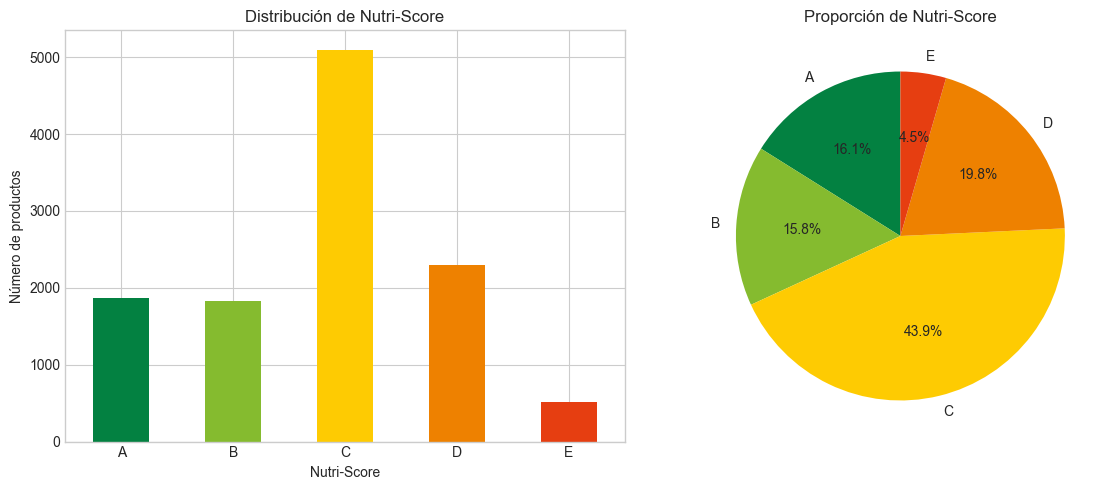

✓ Guardado: nutriscore_distribucion.png


In [9]:
colores_nutriscore = {'A': '#038141', 'B': '#85BB2F', 'C': '#FECB02', 'D': '#EE8100', 'E': '#E63E11'}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Barras
distribucion.plot(kind='bar', ax=axes[0], color=[colores_nutriscore[x] for x in distribucion.index])
axes[0].set_title('Distribución de Nutri-Score')
axes[0].set_xlabel('Nutri-Score')
axes[0].set_ylabel('Número de productos')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

# Pie
axes[1].pie(distribucion.values, labels=distribucion.index, 
            colors=[colores_nutriscore[x] for x in distribucion.index],
            autopct='%1.1f%%', startangle=90)
axes[1].set_title('Proporción de Nutri-Score')

plt.tight_layout()
plt.savefig('../docs/nutriscore_distribucion.png', dpi=150)
plt.show()
print("✓ Guardado: nutriscore_distribucion.png")

In [10]:
# Guardar dataset con Nutri-Score
df.to_csv('../data/processed/cereales_final.csv', index=False)
print("✓ Guardado: cereales_final.csv")

# Guardar modelos k-NN
joblib.dump(knn_norm, '../src/knn_normalizado.pkl')
joblib.dump(knn_pca, '../src/knn_pca.pkl')
joblib.dump(knn_ae, '../src/knn_autoencoder.pkl')
print("✓ Guardado: modelos k-NN")

✓ Guardado: cereales_final.csv
✓ Guardado: modelos k-NN


In [11]:
print("=" * 60)
print("RESUMEN FASE 3: SISTEMA DE SIMILITUD")
print("=" * 60)

print(f"\n1. SISTEMA k-NN")
print(f"   Productos indexados: {len(df)}")
print(f"   Representaciones: normalizado, PCA, autoencoder")

print(f"\n2. TIEMPO DE RESPUESTA")
print(f"   Normalizado:  0.26 ms")
print(f"   PCA:          0.19 ms")
print(f"   Autoencoder:  0.13 ms")

print(f"\n3. NUTRI-SCORE")
for grade in ['A', 'B', 'C', 'D', 'E']:
    count = (df['nutriscore_grade'] == grade).sum()
    pct = count / len(df) * 100
    print(f"   {grade}: {count} ({pct:.1f}%)")

print(f"\n✓ OE2 CUMPLIDO: Tiempo < 2 segundos")
print(f"✓ OE3 CUMPLIDO: Nutri-Score 100% calculado")
print(f"\n✓ Notebook 05 completado")

RESUMEN FASE 3: SISTEMA DE SIMILITUD

1. SISTEMA k-NN
   Productos indexados: 11608
   Representaciones: normalizado, PCA, autoencoder

2. TIEMPO DE RESPUESTA
   Normalizado:  0.26 ms
   PCA:          0.19 ms
   Autoencoder:  0.13 ms

3. NUTRI-SCORE
   A: 1868 (16.1%)
   B: 1831 (15.8%)
   C: 5093 (43.9%)
   D: 2296 (19.8%)
   E: 520 (4.5%)

✓ OE2 CUMPLIDO: Tiempo < 2 segundos
✓ OE3 CUMPLIDO: Nutri-Score 100% calculado

✓ Notebook 05 completado


In [12]:
#EJEMPLOS

In [13]:
cols_mostrar = ['ranking', 'description', 'brand_owner', 'Energy', 
                'Protein', 'Fiber, total dietary', 'Total Sugars', 'Sodium, Na', 'distancia']

def buscar_con_nutriscore(nombre, n=5, rep='normalizado'):
    r = buscar_similares(producto_nombre=nombre, n=n, representacion=rep)
    r = r.merge(df[['fdc_id','nutriscore_grade']], on='fdc_id', how='left')
    return r[cols_mostrar + ['nutriscore_grade']]

# ── EJEMPLO 1: Cheerios ──────────────────────────────────────
print("=" * 65)
print("EJEMPLO 1: Cheerios (General Mills)")
print("=" * 65)
for rep in ['normalizado', 'pca', 'autoencoder']:
    print(f"\n--- {rep.upper()} ---")
    print(buscar_con_nutriscore('cheerios', rep=rep).to_string(index=False))

# ── EJEMPLO 2: Granola ───────────────────────────────────────
print("\n" + "=" * 65)
print("EJEMPLO 2: Granola")
print("=" * 65)
for rep in ['normalizado', 'pca', 'autoencoder']:
    print(f"\n--- {rep.upper()} ---")
    print(buscar_con_nutriscore('granola', rep=rep).to_string(index=False))

# ── EJEMPLO 3: Bran Flakes (comparación PCA vs Autoencoder) ──
print("\n" + "=" * 65)
print("EJEMPLO 3: Bran Flakes - PCA vs Autoencoder")
print("=" * 65)
for rep in ['pca', 'autoencoder']:
    print(f"\n--- {rep.upper()} ---")
    print(buscar_con_nutriscore('bran flakes', rep=rep).to_string(index=False))

EJEMPLO 1: Cheerios (General Mills)

--- NORMALIZADO ---
Producto encontrado: Cheerios Cereal

PRODUCTO ORIGINAL: Cheerios Cereal
Marca: General Mills
Tiempo de búsqueda: 0.34 ms
 ranking                                                                                                         description          brand_owner  Energy  Protein  Fiber, total dietary  Total Sugars  Sodium, Na  distancia nutriscore_grade
       1                                                       MAPLE & BROWN SUGAR CRUNCH FLAVOR OATMEAL, MAPLE; BROWN SUGAR Del Monte Foods Inc.   127.0     4.69                   3.3          7.51       113.0   0.471265                A
       2 MAPLE & BROWN SUGAR CRUNCH FLAVOR OATMEAL WITH APPLES, GRANOLA, ALMONDS & PUMPKIN SEEDS, MAPLE & BROWN SUGAR CRUNCH Del Monte Foods Inc.   127.0     4.69                   3.3          7.51       113.0   0.471265                A
       3                                                                      APPLE CINNAMON CRUNCH OATM